In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error ,mean_squared_error,r2_score
import numpy as np
data=pd.read_csv("../data/Clean_Dataset.csv")

In [ ]:
# frequency in file

def repeated_word():

    word=str(input("enter the word that you want count her repetion "))
    number_of_word = 0

    for column in data.columns:
        for value in data[column]:
         if word.lower() in str(value).lower():
            number_of_word += 1

    return number_of_word


print(repeated_word())

In [ ]:
# frequency de chaque word in column

column=str(input("enter the column that you want count her repetion "))
word=str(input("enter the word that you want count her repetion "))
def repeated_word():

    repeated_in_column = data[column].value_counts()
    number_of_word = (data[column] == word).sum()

    return repeated_in_column, number_of_word


print(repeated_word())

In [ ]:

def  cherger_maque_value():
    number_of_missing = data.isnull().sum().sum()

    return number_of_missing


print(cherger_maque_value())

In [13]:
discre_columns = [
    "airline",
    "flight",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

continue_columns = [
    "duration",
    "days_left",
    "price"
]


categorical_data = data[discre_columns]
quantitative_data = data[continue_columns]


print(categorical_data ," hhhh \n")
print(quantitative_data ,"\n")

         airline   flight source_city departure_time stops   arrival_time  \
0       SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1       SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2        AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3        Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4        Vistara   UK-963       Delhi        Morning  zero        Morning   
...          ...      ...         ...            ...   ...            ...   
300148   Vistara   UK-822     Chennai        Morning   one        Evening   
300149   Vistara   UK-826     Chennai      Afternoon   one          Night   
300150   Vistara   UK-832     Chennai  Early_Morning   one          Night   
300151   Vistara   UK-828     Chennai  Early_Morning   one        Evening   
300152   Vistara   UK-822     Chennai        Morning   one        Evening   

       destination_city     class  
0                Mumbai   Economy  
1  

analyse univariee

la partie des variable contenue 

In [15]:
print(quantitative_data.describe())

            duration      days_left          price
count  300153.000000  300153.000000  300153.000000
mean       12.221021      26.004751   20889.660523
std         7.191997      13.561004   22697.767366
min         0.830000       1.000000    1105.000000
25%         6.830000      15.000000    4783.000000
50%        11.250000      26.000000    7425.000000
75%        16.170000      38.000000   42521.000000
max        49.830000      49.000000  123071.000000


Et ton describe() montre notamment que price est très dispersé : moyenne ≈ 20 890, médiane ≈ 7 425, maximum ≈ 123 071. Cette différence entre moyenne et médiane suggère déjà une distribution du prix probablement asymétrique vers les grandes valeurs.

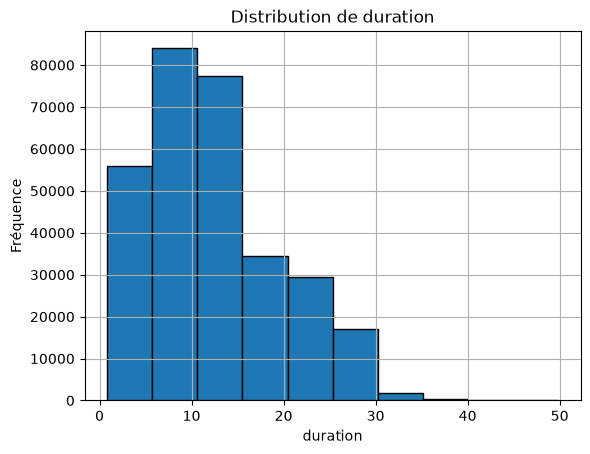

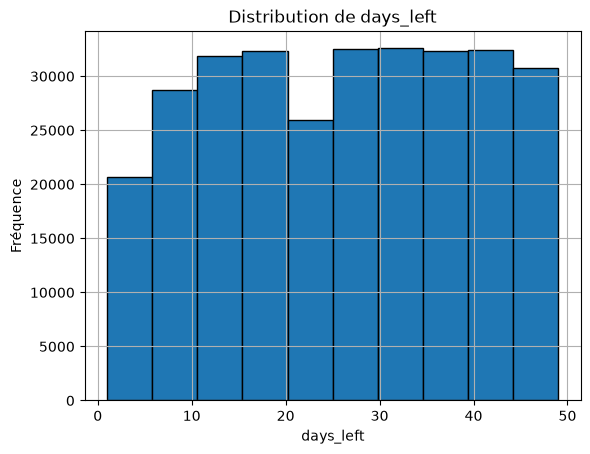

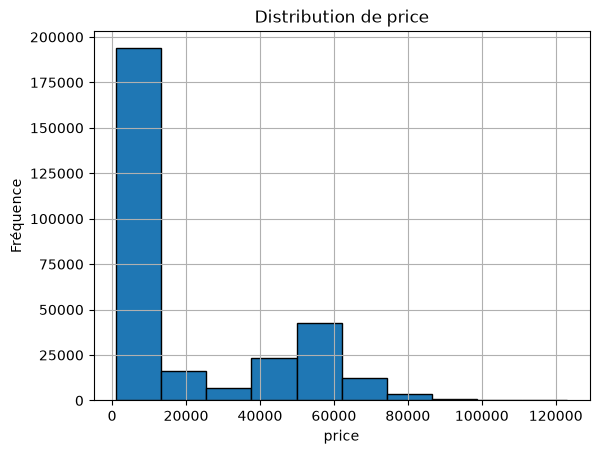

In [16]:
for column in quantitative_data:
    data[column].hist(edgecolor="black",linewidth=1)
    plt.title(f"Distribution de {column}")
    plt.xlabel(column)
    plt.ylabel("Fréquence")
 
    plt.show()

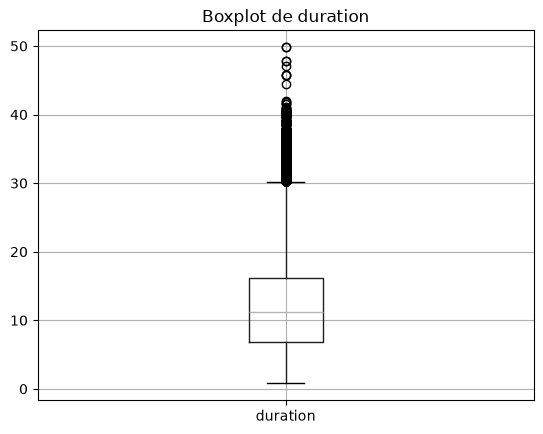

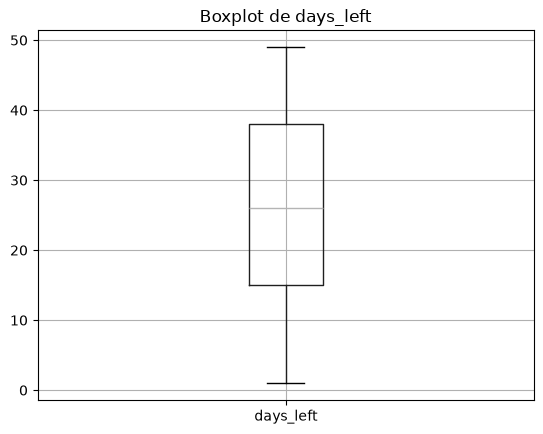

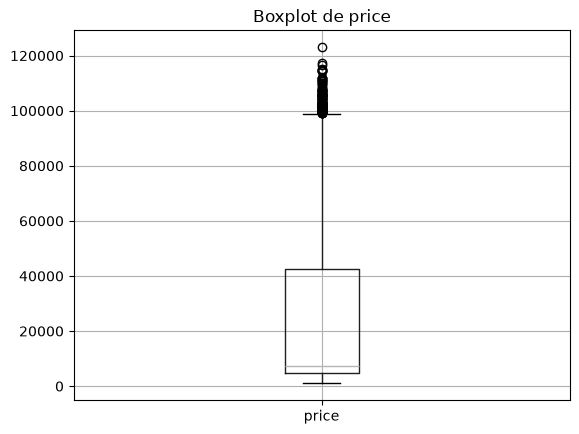

In [17]:
for column in quantitative_data:
    data.boxplot(column=column)
    plt.title(f"Boxplot de {column}")
    plt.show()

Pour les variables catégorielles, utilise surtout des barplots :

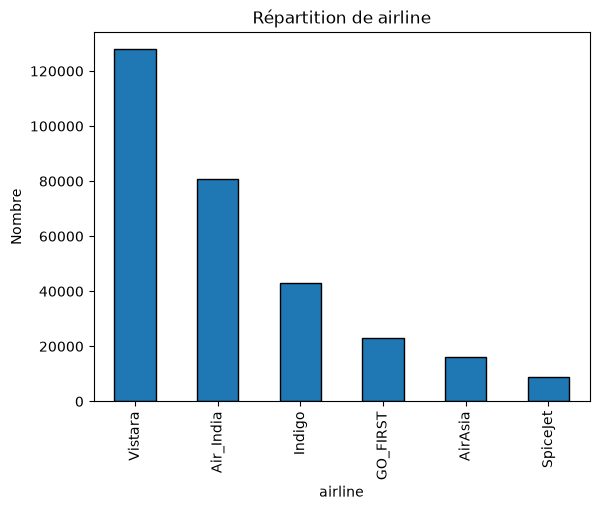

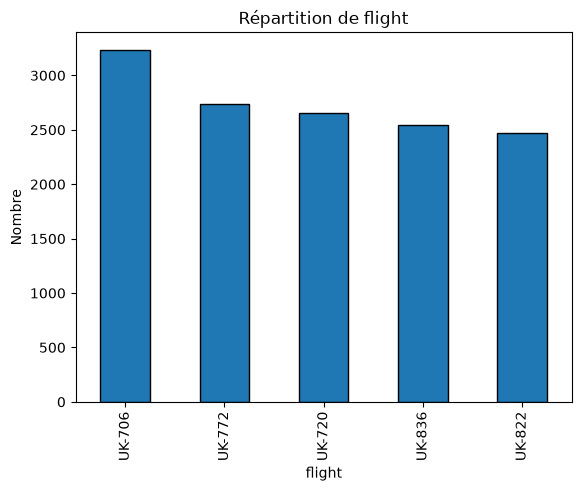

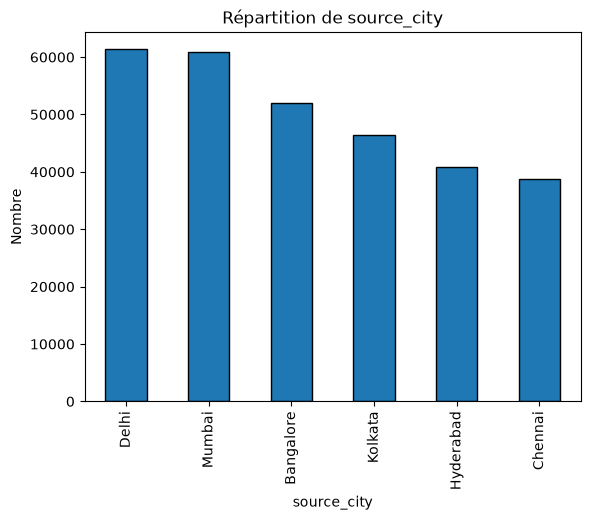

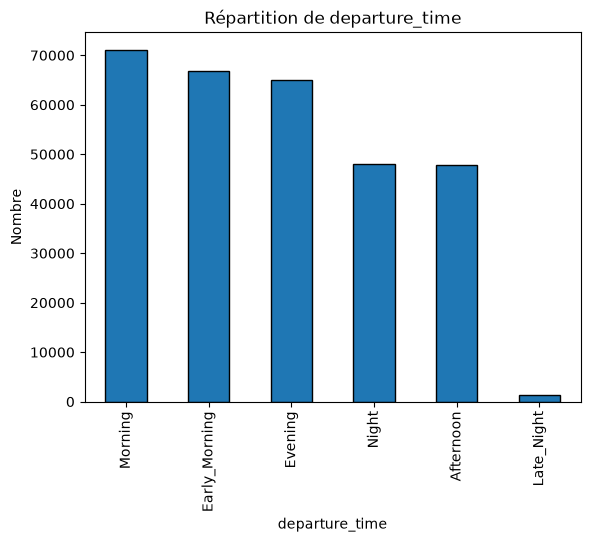

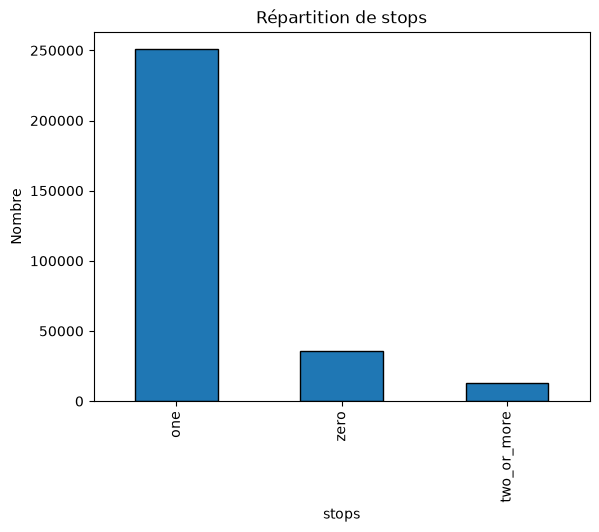

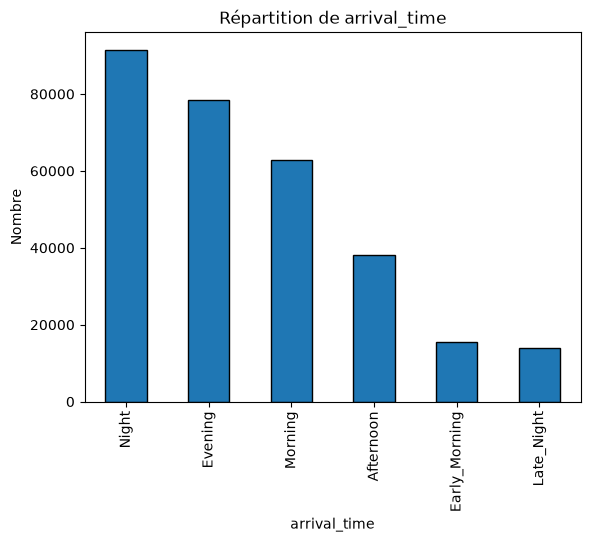

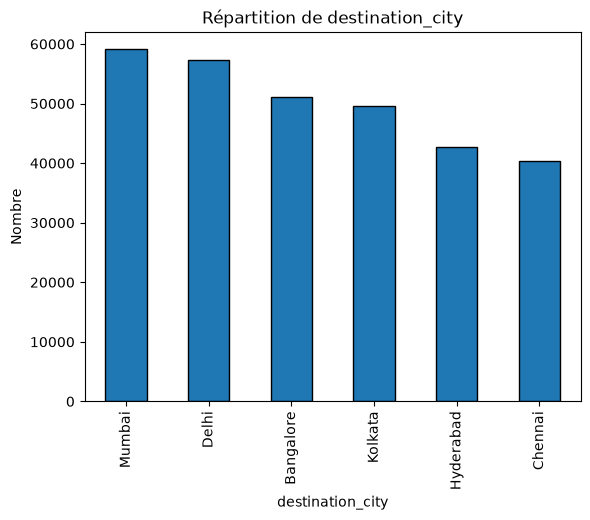

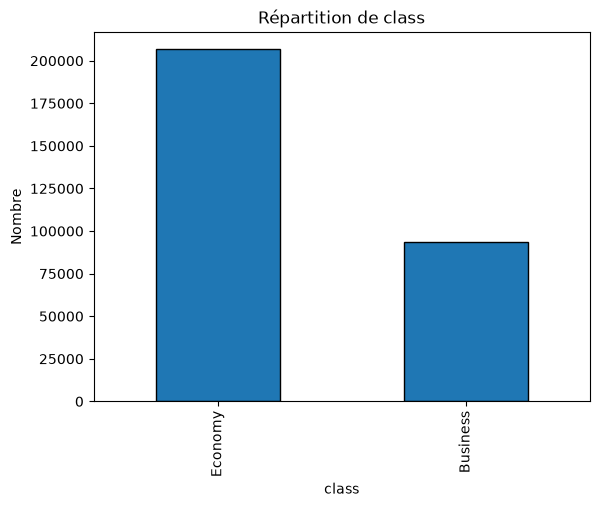

In [18]:
import matplotlib.pyplot as plt

for column in categorical_data:

    if column == "flight":
        data[column].value_counts().head().plot(
            kind="bar",
            edgecolor="black"
        )
    else:
        data[column].value_counts().plot(
            kind="bar",
            edgecolor="black"
        )

    plt.title(f"Répartition de {column}")
    plt.xlabel(column)
    plt.ylabel("Nombre")
    plt.show()

calcule multie varie 

    calculer correlation 

In [19]:
print(quantitative_data.corr())

           duration  days_left     price
duration   1.000000  -0.039157  0.204222
days_left -0.039157   1.000000 -0.091949
price      0.204222  -0.091949  1.000000


In [20]:
data[["duration","price"]].corr()

,duration,price
duration,1.000000,0.204222
price,0.204222,1.000000


 Points qui montent → corrélation positive : quand la durée augmente, le prix tend à augmenter.
 Points qui descendent → corrélation négative.
 Points très dispersés → relation faible ou inexistante.
 Points très éloignés du nuage → valeurs atypiques (outliers)

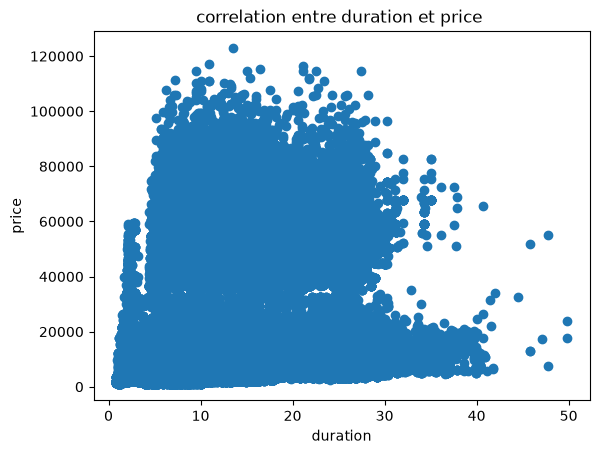

In [21]:
plt.scatter(data["duration"],data["price"])
plt.xlabel("duration")
plt.ylabel("price")
plt.title("correlation entre duration et price ")
plt.show()

j observe que  le prix ne depasse pas par des grande valeur   100000 entre intervalle de duree 5 et 30 mais s il depasse  30 dans duration le prix deminuer <4000

In [22]:
print(
    data.groupby("airline")["price"]
    .agg(["mean","median","min","max"])
    .sort_values("mean")
)

                   mean   median   min     max
airline                                       
AirAsia     4091.072742   3276.0  1105   31917
Indigo      5324.216303   4453.0  1105   31952
GO_FIRST    5652.007595   5336.0  1105   32803
SpiceJet    6179.278881   5654.0  1106   34158
Air_India  23507.019112  11520.0  1526   90970
Vistara    30396.536302  15543.0  1714  123071


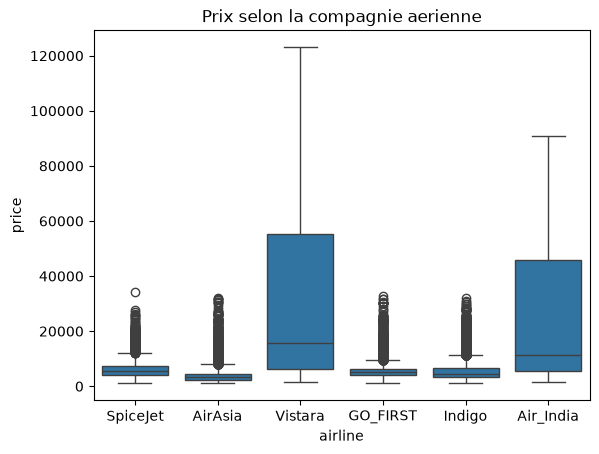

In [23]:

sns.boxplot(data=data, x="airline", y="price")
plt.title("Prix selon la compagnie aerienne")
plt.show()

on observe que AIRASIA AND AIR_INDIA  ont des prix  ont beacoup des prix antre 4500 et 6000 mais la ligne de q50% deminuer signifie on des valeur avoir bais vers les valeur ptites mais les airline <2000 et le mediane a une approximation tres fin entre median et moyen

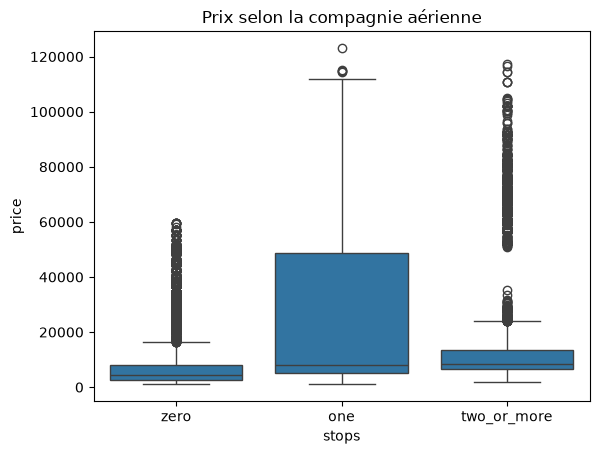

In [24]:
sns.boxplot(data=data, x="stops", y="price")
plt.title("Prix selon la compagnie aérienne")
plt.show()

pour les stpos on observe one avoir prix grand et meme temp le la ligne de q50 under le motier signifier on le moyenne et le median sont disperser par des valeur ayant bais <1000

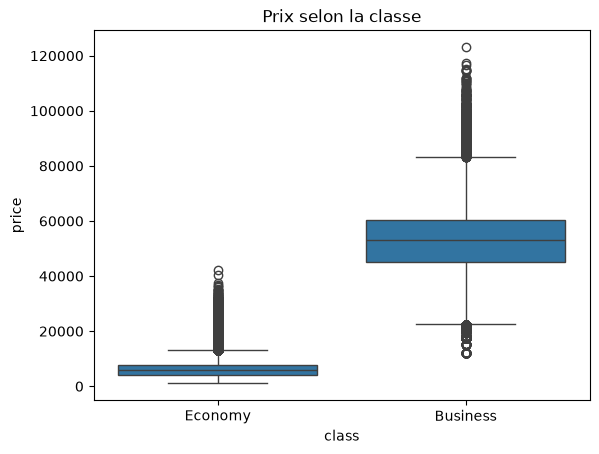

In [25]:
sns.boxplot(data=data, x="class", y="price")
plt.title("Prix selon la classe")
plt.show()

ona pour economy on des valeur <2000 ont le moyenne et median dans la meme endroit  ona pas des valeur outlaiers  mais business class entre 2000 et 8000 les velur sont homgene pas de bais dominante 

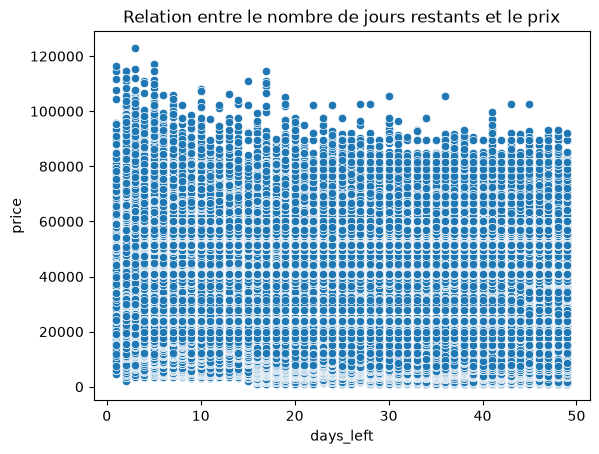

In [26]:
sns.scatterplot(data=data, x="days_left", y="price")
plt.title("Relation entre le nombre de jours restants et le prix")
plt.show()

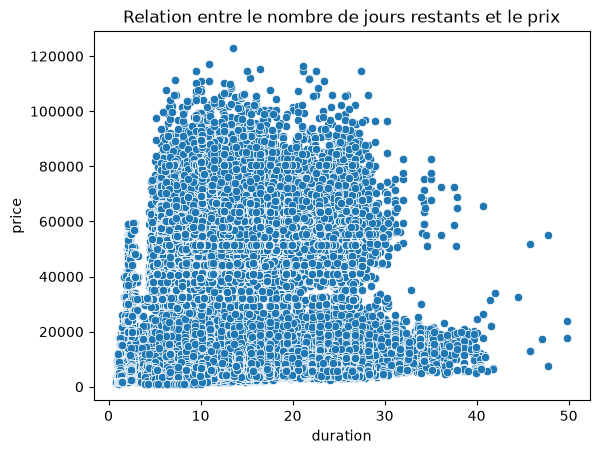

In [27]:
sns.scatterplot(data=data, x="duration", y="price")
plt.title("Relation entre le nombre de jours restants et le prix")
plt.show()

LE PREPROCESSION 

verifier data that is null

In [28]:
data.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

duplication de data


In [ ]:
data.duplicated().sum()
data.dtypes

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

encodage des valeur categorillle 


In [29]:

x = data.drop(["price", "flight"], axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:


ordinal=[
    "class",
    "stops",
]
non_ordinale=[
    "destination_city",
    "airline",
   "source_city",
   "departure_time",
   "arrival_time",


]
numeric_features = [
    "duration",
    "days_left"
]




encoder=OneHotEncoder(
    handle_unknown="ignore",
     sparse_output=False
)


encoded =encoder.fit_transform(data[non_ordinale])
print( encoded)

[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [3]:
print("hello")

hello


on fait la partie de division des donnes 

separation des données

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "ord",
            OrdinalEncoder(
                categories=[
                    ["Economy", "Business"],
                    ["zero", "one", "two_or_more"]
                ],
                handle_unknown="use_encoded_value",
                
           
            ),
            ordinal
        ),
        (
            "nom",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            non_ordinale
        )
    ]
)

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [45]:
model =Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor",LinearRegression())
])

In [46]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Unnamed: 0','airline','source_city',...,'class','duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [51]:
test = pd.DataFrame([{
    "airline": "SpiceJet",
    "source_city": "Mumbai",
    "departure_time": "Evening",
    "stops": "zero",
    "arrival_time": "Night",
    "destination_city": "Mumbai",
    "class": "Economy",
    "duration": 2.17,
    "days_left": 1
}])

evaluation du model

In [52]:

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# y_pred=model.predict(test)
# print(y_pred)

[4957.66428293]


ensemble des valeur 

In [53]:
y_pred=model.predict(X_test)

In [54]:
mae=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print("MAE" , mae)
print("RMSE" ,rmse)
print("R2", r2)

MAE 46443349.49336858
RMSE 6814.935765901875
R2 0.909903110398299


faire une comparaison

In [55]:
import pandas as pd
comparaison=pd.DataFrame({
    "prix_reel":y_test.values,
    "prix_predit":y_pred
})
print(comparaison.head(10))

   prix_reel   prix_predit
0       7366   3151.379989
1      64831  54895.604479
2       6195   9856.943483
3      60160  54718.399810
4       6578   6049.901099
5       4555   9047.846608
6      23838  49493.842213
7       3860   5990.326781
8      32230  49688.734767
9      76841  58758.046716


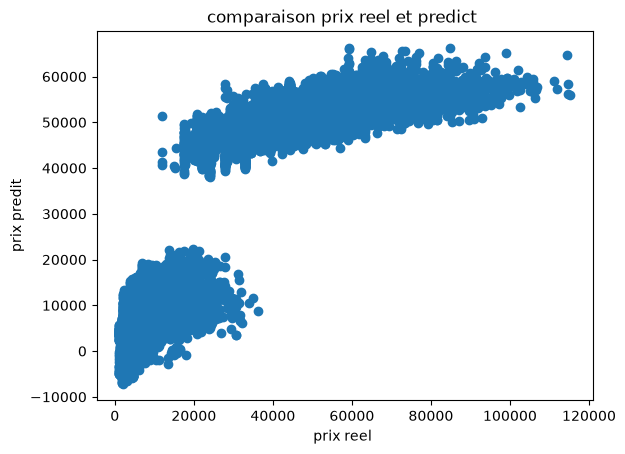

In [58]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("prix reel ")
plt.ylabel("prix predit")
plt.title("comparaison prix reel et predict ")
plt.show()

exporter pipline


In [64]:
import joblib 

joblib.dump(model,"model.joblib")

['model.joblib']

In [67]:
from sklearn.utils.validation import check_is_fitted
model_loaded = joblib.load("model.joblib")
model = joblib.load("model.joblib")
y_pred_loaded = model_loaded.predict(X_test)

print(y_pred_loaded[:5])


[ 3151.37998934 54895.60447899  9856.94348306 54718.39980954
  6049.90109876]
